# SUPPORT VECTOR MACHINE

In [ ]:
SUPPORT VECTOR MACHINE
1)Read CSV file
2)Check Null Value
3)Define X & y
4)Split data Into train and test
5)Train SVM Model
6)Model fit in Linear regression
7)Prediction
8)Model Evaluation
9)Assigning CM Values
10)Calculate Metrics

In [19]:
import pandas as pd 
df=pd.read_csv("Employee_Attrition.csv")
df

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0
...,...,...,...,...,...,...,...,...,...,...,...
245,246,46,39369,7,Developer,Excellent,Yes,2,1,Graduate,0
246,247,42,74890,4,HR,Excellent,Yes,4,17,Postgraduate,0
247,248,52,116447,1,Manager,Excellent,Yes,3,22,Graduate,0
248,249,55,69391,10,Manager,Good,No,3,22,Postgraduate,0


In [20]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [21]:
df.drop(columns="Employee_ID",inplace=True)
df

,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,56,31395,18,HR,Poor,Yes,1,7,School,1
2,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,39,20851,5,HR,Good,No,2,7,Graduate,0
4,28,32156,12,Developer,Good,No,3,26,School,0
...,...,...,...,...,...,...,...,...,...,...
245,46,39369,7,Developer,Excellent,Yes,2,1,Graduate,0
246,42,74890,4,HR,Excellent,Yes,4,17,Postgraduate,0
247,52,116447,1,Manager,Excellent,Yes,3,22,Graduate,0
248,55,69391,10,Manager,Good,No,3,22,Postgraduate,0


In [22]:
df=pd.get_dummies(data=df,drop_first=True)
df

,Age,Monthly_Income,Years_at_Company,Job_Satisfaction,Distance_From_Home,Attrition,Job_Role_Developer,Job_Role_HR,Job_Role_Manager,Work_Life_Balance_Good,Work_Life_Balance_Poor,Overtime_Yes,Education_Postgraduate,Education_School
0,29,23278,8,1,22,1,False,False,True,False,True,True,True,False
1,56,31395,18,1,7,1,False,True,False,False,True,True,False,True
2,54,98907,0,2,15,0,False,False,True,False,False,False,True,False
3,39,20851,5,2,7,0,False,True,False,True,False,False,False,False
4,28,32156,12,3,26,0,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,46,39369,7,2,1,0,True,False,False,False,False,True,False,False
246,42,74890,4,4,17,0,False,True,False,False,False,True,True,False
247,52,116447,1,3,22,0,False,False,True,False,False,True,False,False
248,55,69391,10,3,22,0,False,False,True,True,False,False,True,False


In [23]:
X = df.drop(columns=['Attrition']) 
y = df['Attrition']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (250, 13)
y shape: (250,)


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)

Training data size: (200, 13)
Testing data size: (50, 13)
Training data size: (200,)
Testing data size: (50,)


In [25]:
from sklearn.svm import SVC
model=SVC(C=10,random_state=42)
model

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[47,  0],
       [ 3,  0]])

In [30]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)


True Negative: 47
False Positive: 0
False Negative: 3
True Positive: 0


In [31]:
accuracy = (TP + TN) / (TN + FP + FN + TP)
error_rate = (FP + FN) / (TN + FP + FN + TP)
precision = TP / (TP + FP) 
specificity = TN / (TN + FP)
Sensitivity = TP / (TP + FN) 
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", Sensitivity)
print("Specificity:", specificity)

Accuracy: 0.94
Error Rate: 0.06
Precision: nan
Recall: 0.0
Specificity: 1.0


C:\Users\LJENG\AppData\Local\Temp\ipykernel_15328\363260954.py:3: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


In [32]:
y_pred=model.predict([[30,45000,5,3,10,1,0,0,1,0,1,0,0]])
y_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

# 9Marks

In [37]:
import pandas as pd 
df=pd.read_csv("Employee_Attrition.csv")
df
df.isna().sum()
df.drop(columns="Employee_ID",inplace=True)
df
df=pd.get_dummies(data=df,drop_first=True)
df
X = df.drop(columns=['Attrition']) 
y = df['Attrition']
print("X shape:", X.shape)
print("y shape:", y.shape)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Training data size:", y_train.shape)
print("Testing data size:", y_test.shape)


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
Accuracy=[]
Neighbor=[]
for i in range(1,26):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    Accuracy.append(accuracy_score(y_test,y_pred))
    Neighbor.append(i)
best_k=Accuracy.index(max(Accuracy))+1
best_k

X shape: (250, 13)
y shape: (250,)
Training data size: (200, 13)
Testing data size: (50, 13)
Training data size: (200,)
Testing data size: (50,)


2

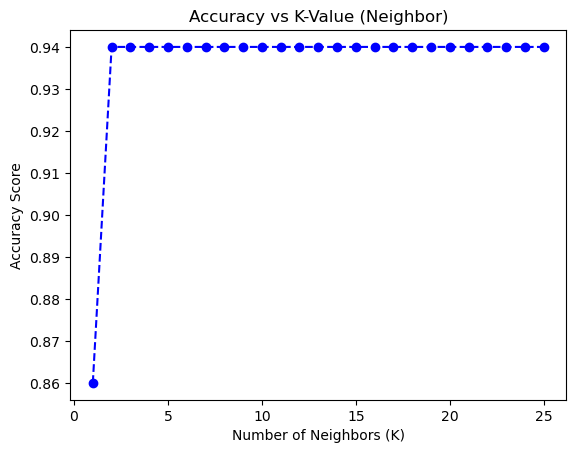

Best K found at: 2


In [40]:
import matplotlib.pyplot as plt
plt.plot(Neighbor, Accuracy, marker='o', linestyle='--', color='b')
plt.title('Accuracy vs K-Value (Neighbor)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.show()

print("Best K found at:", best_k)

## Example

In [ ]:
predict=charges
test_size=0.1 to 0.5
random_state=1 to 50
find best Model height
accuracy & lowest MSE
multiple linear regression

In [56]:
import pandas as pd
import numpy as np
df=pd.read_csv("insurance.csv")
df
df.isna().sum()
df = pd.get_dummies(df, drop_first=True)
df
X = df.drop(columns=['charges'])
y = df['charges']
print("X shape:", X.shape)
print("y shape:", y.shape)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
test=[0.1,0.2,0.3,0.4,0.5]
T=[]
R=[]
MSE=[]
for i in test:
    for j in range(1,51):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=i, random_state=j)
        lr=LinearRegression()
        lr.fit(X_train,y_train)
        y_pred=lr.predict(X_test)
        MSE.append(mean_squared_error(y_test,y_pred))
        R.append(j)
        T.append(i)

X shape: (1338, 8)
y shape: (1338,)


In [62]:
data={"test_size":T,"random_state":R,"MSE":MSE}
df=pd.DataFrame(data)
df

,test_size,random_state,MSE
0,0.1,1,4.309228e+07
1,0.1,2,3.389797e+07
2,0.1,3,3.951443e+07
3,0.1,4,3.988952e+07
4,0.1,5,3.123591e+07
...,...,...,...
245,0.5,46,3.709642e+07
246,0.5,47,3.420950e+07
247,0.5,48,3.501184e+07
248,0.5,49,3.625246e+07


In [63]:
df['MSE'].min()

25964185.138925117

In [64]:
df[df["MSE"]==25964185.138925117]

,test_size,random_state,MSE
35,0.1,36,2.596419e+07
